In [ ]:
!pip install -q torchmil timm huggingface_hub

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import cv2
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import timm
from huggingface_hub import login
import matplotlib.pyplot as plt
from torchvision.transforms import v2  # Use v2 for AugMix/RandAugment support

# TorchMIL imports
from torchmil.models import MILModel
from torchmil.nn import AttentionPool
from torchmil.datasets import ProcessedMILDataset
from torchmil.data import collate_fn as mil_collate_fn

# --- Config ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda


In [2]:
from kaggle_secrets import UserSecretsClient

try:
    hf_token = UserSecretsClient().get_secret("HUGGINGFACE_TOKEN")
    login(token=hf_token)
    print("Logged in to Hugging Face successfully.")
except Exception as e:
    print(f"Authentication warning: {e}")
    print("Ensure you have set the 'HUGGINGFACE_TOKEN' secret to access UNI2-h.")


Logged in to Hugging Face successfully.


In [3]:
# Paths
# DATA_PATH = Path('/kaggle/input/grumpy-doctogres/an2dl2526c2v2/an2dl2526c2v2')
# TRAIN_LABELS = DATA_PATH / 'train_labels.csv'
# PATCHES_BASE = Path('/kaggle/input/grumpy-doctogres/patches_region_min112_max224_tiny_margin/patches_region_min112_max224_tiny_margin')
# TRAIN_PATCHES_PATH = PATCHES_BASE / 'train_data'
# TEST_PATCHES_PATH = PATCHES_BASE / 'test_data'
# TRAIN_PATCHES_CSV = PATCHES_BASE / 'train_data_patches_region.csv'
# TEST_PATCHES_CSV = PATCHES_BASE / 'test_data_patches_region.csv'

PATCHES_BASE = Path('/kaggle/input/grumpy-doctogres/')
TRAIN_LABELS = PATCHES_BASE / 'train_labels.csv'
TRAIN_PATCHES_PATH = PATCHES_BASE / 'train/imgs'
TEST_PATCHES_PATH = PATCHES_BASE / 'test/imgs'
TRAIN_PATCHES_CSV = PATCHES_BASE / 'train_patches.csv'
TEST_PATCHES_CSV = PATCHES_BASE / 'test_patches.csv'

OUTPUT_PATH = Path('/kaggle/working/')
OUTPUT_PATH.mkdir(exist_ok=True)
FEATURES_PATH = OUTPUT_PATH / 'train_features'
TEST_FEATURES_PATH = OUTPUT_PATH / 'test_features'

In [17]:
# Params

PATCH_SIZE = 224
N_FOLDS = 5

BATCH_SIZE = 256

NUM_EPOCHS = 1000
PATIENCE = 50
SCHEDULER_PATIENCE=40

WEIGHT_DECAY=1e-6
LEARNING_RATE = 3e-3

ATTENTION_DIM=8
GATED=True

DROPOUT=0.5

# Augmentation
N_AUGMENTATIONS=0

In [5]:
def doubling_frequency256(state):
    global counter
    if "last_update" not in state:
        state["last_update"] = 0
        counter = 1
        return True

    if state['step'] - state['last_update'] >= state['precondition_frequency']:
        state['last_update'] = state['step']
        state['precondition_frequency'] = min(256, state['precondition_frequency']*2)  # Clip the frequency to max 256
        counter += 1
        return True
    else:
        return False

# Courtesy of https://github.com/nikhilvyas/SOAP/blob/main/soap.py, one of the co-authors of the original SOAP paper

import torch.optim as optim

from itertools import chain

from typing import Callable            # Our addition

# Parts of the code are modifications of Pytorch's AdamW optimizer
# Parts of the code are modifications of code from https://github.com/jiaweizzhao/GaLore/blob/master/galore_torch/galore_projector.py

class SOAP(optim.Optimizer):
    """
    Implements SOAP algorithm (https://arxiv.org/abs/2409.11321).

    Parameters:
        params (`Iterable[nn.parameter.Parameter]`):
            Iterable of parameters to optimize or dictionaries defining parameter groups.
        lr (`float`, *optional*, defaults to 0.003):
            The learning rate to use.
        betas (`Tuple[float,float]`, *optional*, defaults to `(0.95, 0.95)`):
            Adam's betas parameters (b1, b2).
        shampoo_beta (`float`, *optional*, defaults to -1):
            If >= 0, use this beta for the preconditioner (L and R in paper, state['GG'] below) moving average instead of betas[1].
        eps (`float`, *optional*, defaults to 1e-08):
            Adam's epsilon for numerical stability.
        weight_decay (`float`, *optional*, defaults to 0.01): weight decay coefficient.
        precondition_frequency (`int`, *optional*, defaults to 10):
            How often to update the preconditioner.
        precondition_frequency_routine (`Callable`, *optional*, defaults to the constant frequency lambda):           # Our addition:
            Change the frequeny of preconditioner updates.
        max_precond_dim (`int`, *optional*, defaults to 10000):
            Maximum dimension of the preconditioner.
            Set to 10000, so that we exclude most common vocab sizes while including layers.
        merge_dims (`bool`, *optional*, defaults to `False`):
            Whether or not to merge dimensions of the preconditioner.
        precondition_1d (`bool`, *optional*, defaults to `False`):
            Whether or not to precondition 1D gradients.
        normalize_grads (`bool`, *optional*, defaults to `False`):
            Whether or not to normalize gradients per layer.
            Helps at large precondition_frequency (~100 in our experiments),
            but hurts performance at small precondition_frequency (~10 in our experiments).
        data_format (`str`, *optional*, defaults to `channels_first`):
            Data format of the input for convolutional layers.
            Should be "channels_last" for data_format of NHWC and "channels_first" for NCHW.
        correct_bias (`bool`, *optional*, defaults to `True`):
            Whether or not to use bias correction in Adam.
    """

    def __init__(
        self,
        params,
        lr: float = 3e-3,
        betas=(0.95, 0.95),
        shampoo_beta: float= -1,
        eps: float = 1e-8,
        weight_decay: float = 0.01,
        precondition_frequency: int=10,
        precondition_frequency_routine: Callable=doubling_frequency256,            # Our addition
        max_precond_dim: int=10000, #
        merge_dims: bool = False, # Merge dimensions till the product of the dimensions is less than or equal to max_precond_dim.
        precondition_1d: bool = False,
        normalize_grads: bool = False,
        data_format: str = "channels_first",
        correct_bias: bool = True,
    ):
        defaults = {
            "lr": lr,
            "betas": betas,
            "shampoo_beta": shampoo_beta,
            "eps": eps,
            "weight_decay": weight_decay,
            "precondition_frequency": precondition_frequency,
            "precondition_frequency_routine": precondition_frequency_routine,           # Our addition
            "max_precond_dim": max_precond_dim,
            "merge_dims": merge_dims,
            "precondition_1d": precondition_1d,
            "normalize_grads": normalize_grads,
            "correct_bias": correct_bias,
        }
        super().__init__(params, defaults)
        self._data_format = data_format

    def merge_dims(self, grad, max_precond_dim):
        """
        Merges dimensions of the gradient tensor till the product of the dimensions is less than or equal to max_precond_dim.
        """
        assert self._data_format in ["channels_first", "channels_last"]
        if self._data_format == "channels_last" and grad.dim() == 4:
            grad = grad.permute(0, 3, 1, 2)
        shape = grad.shape
        new_shape = []

        curr_shape = 1
        for sh in shape:
            temp_shape = curr_shape * sh
            if temp_shape > max_precond_dim:
                if curr_shape > 1:
                    new_shape.append(curr_shape)
                    curr_shape = sh
                else:
                    new_shape.append(sh)
                    curr_shape = 1
            else:
                curr_shape = temp_shape

        if curr_shape > 1 or len(new_shape)==0:
            new_shape.append(curr_shape)

        new_grad = grad.reshape(new_shape)
        return new_grad

    @torch.no_grad()
    def step(self, closure = None):
        """
        Performs a single optimization step.

        Arguments:
            closure (`Callable`, *optional*): A closure that reevaluates the model and returns the loss.
        """
        if closure is None:
            loss = None
        else:
            loss = closure()

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad

                state = self.state[p]

                if "step" not in state:
                    state["step"] = 0

                # State initialization
                if "exp_avg" not in state:
                    # Exponential moving average of gradient values
                    state["exp_avg"] = torch.zeros_like(grad)
                    # Exponential moving average of squared gradient values
                    state["exp_avg_sq"] = torch.zeros_like(grad)

                if 'Q' not in state:
                    self.init_preconditioner(
                        grad,
                        state,
                        precondition_frequency=group['precondition_frequency'],
                        precondition_frequency_routine=group['precondition_frequency_routine'],           # Our addition
                        precondition_1d=group['precondition_1d'],
                        shampoo_beta=(group['shampoo_beta'] if group['shampoo_beta'] >= 0 else group["betas"][1]),
                        max_precond_dim=group['max_precond_dim'],
                        merge_dims=group["merge_dims"],
                    )
                    self.update_preconditioner(grad, state,
                                               max_precond_dim=group['max_precond_dim'],
                                               merge_dims=group["merge_dims"],
                                               precondition_1d=group["precondition_1d"])
                    continue # first step is skipped so that we never use the current gradients in the projection.

                state["loss"] = loss            # Our addition

                # Projecting gradients to the eigenbases of Shampoo's preconditioner
                # i.e. projecting to the eigenbases of matrices in state['GG']
                grad_projected = self.project(grad, state, merge_dims=group["merge_dims"],
                                              max_precond_dim=group['max_precond_dim'])

                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                beta1, beta2 = group["betas"]

                state["step"] += 1

                # Decay the first and second moment running average coefficient
                # In-place operations to update the averages at the same time
                exp_avg.mul_(beta1).add_(grad_projected, alpha=(1.0 - beta1))
                exp_avg_sq.mul_(beta2).add_(grad_projected.square(), alpha=(1.0 - beta2))

                denom = exp_avg_sq.sqrt().add_(group["eps"])

                # Projecting the exponential moving average of gradients to the eigenbases of Shampoo's preconditioner
                # i.e. projecting to the eigenbases of matrices in state['GG']
                # exp_avg_projected = self.project(exp_avg, state, merge_dims=group["merge_dims"],
                #                                  max_precond_dim=group['max_precond_dim'])
                exp_avg_projected = exp_avg

                step_size = group["lr"]
                if group["correct_bias"]:
                    bias_correction1 = 1.0 - beta1 ** (state["step"])
                    bias_correction2 = 1.0 - beta2 ** (state["step"])
                    step_size = step_size * (bias_correction2 ** .5) / bias_correction1

                # Projecting back the preconditioned (by Adam) exponential moving average of gradients
                # to the original space
                norm_grad = self.project_back(exp_avg_projected / denom, state, merge_dims=group["merge_dims"],
                                                 max_precond_dim=group['max_precond_dim'])

                if group["normalize_grads"]:
                    norm_grad = norm_grad / (1e-30+torch.mean(norm_grad**2)**0.5)

                p.add_(norm_grad, alpha=-step_size)


                # From AdamW code: Just adding the square of the weights to the loss function is *not*
                # the correct way of using L2 regularization/weight decay with Adam,
                # since that will interact with the m and v parameters in strange ways.
                #
                # Instead we want to decay the weights in a manner that doesn't interact
                # with the m/v parameters. This is equivalent to adding the square
                # of the weights to the loss with plain (non-momentum) SGD.
                # Add weight decay at the end (fixed version)
                if group["weight_decay"] > 0.0:
                    p.add_(p, alpha=(-group["lr"] * group["weight_decay"]))

                # Update is done after the gradient step to avoid using current gradients in the projection.
                self.update_preconditioner(grad, state,
                                               max_precond_dim=group['max_precond_dim'],
                                               merge_dims=group["merge_dims"],
                                               precondition_1d=group["precondition_1d"])

        return loss

    def init_preconditioner(self, grad, state, precondition_frequency=10, precondition_frequency_routine=lambda state: state['step'] % state['precondition_frequency'] == 0, # Our addition
                            shampoo_beta=0.95, max_precond_dim=10000, precondition_1d=False,
                            merge_dims=False):
        """
        Initializes the preconditioner matrices (L and R in the paper).
        """
        state['GG'] = [] # Will hold all the preconditioner matrices (L and R in the paper).
        if grad.dim() == 1:
            if not precondition_1d or grad.shape[0] > max_precond_dim:
                state['GG'].append([])
            else:
                state['GG'].append(torch.zeros(grad.shape[0], grad.shape[0], device=grad.device))
        else:
            if merge_dims:
                grad = self.merge_dims(grad, max_precond_dim)

            for sh in grad.shape:
                if sh > max_precond_dim:
                    state['GG'].append([])
                else:
                    state['GG'].append(torch.zeros(sh, sh, device=grad.device))

        state['Q'] = None # Will hold all the eigenbases of the preconditioner.
        state['precondition_frequency'] = precondition_frequency
        state['precondition_frequency_routine'] = precondition_frequency_routine            # Our addition
        state['shampoo_beta'] = shampoo_beta

    def project(self, grad, state, merge_dims=False, max_precond_dim=10000):
        """
        Projects the gradient to the eigenbases of the preconditioner.
        """
        original_shape = grad.shape
        if merge_dims:
            if grad.dim() == 4 and self._data_format == 'channels_last':
                permuted_shape = grad.permute(0, 3, 1, 2).shape
            grad = self.merge_dims(grad, max_precond_dim)

        for mat in state['Q']:
            if len(mat) > 0:
                grad = torch.tensordot(
                        grad,
                        mat,
                        dims=[[0], [0]],
                    )
            else:
                permute_order = list(range(1, len(grad.shape))) + [0]
                grad = grad.permute(permute_order)

        if merge_dims:
            if self._data_format == 'channels_last' and len(original_shape) == 4:
                grad = grad.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                grad = grad.reshape(original_shape)
        return grad

    def update_preconditioner(self, grad, state,
                              max_precond_dim=10000, merge_dims=False, precondition_1d=False):
        """
        Updates the preconditioner matrices and the eigenbases (L, R, Q_L, Q_R in the paper).
        """
        if state["Q"] is not None:
            state["exp_avg"] = self.project_back(state["exp_avg"], state, merge_dims=merge_dims, max_precond_dim=max_precond_dim)
        if grad.dim() == 1:
            if precondition_1d and grad.shape[0] <= max_precond_dim:
                state['GG'][0].lerp_(grad.unsqueeze(1) @ grad.unsqueeze(0), 1-state['shampoo_beta'])
        else:
            if merge_dims:
                new_grad = self.merge_dims(grad, max_precond_dim)
                for idx, sh in enumerate(new_grad.shape):
                    if sh <= max_precond_dim:
                        outer_product = torch.tensordot(
                                new_grad,
                                new_grad,
                                dims=[[*chain(range(idx), range(idx + 1, len(new_grad.shape)))]] * 2,
                            )
                        state['GG'][idx].lerp_(outer_product, 1-state['shampoo_beta'])
            else:
                for idx, sh in enumerate(grad.shape):
                    if sh <= max_precond_dim:
                        outer_product = torch.tensordot(
                                grad,
                                grad,
                                # Contracts across all dimensions except for k.
                                dims=[[*chain(range(idx), range(idx + 1, len(grad.shape)))]] * 2,
                            )
                        state['GG'][idx].lerp_(outer_product, 1-state['shampoo_beta'])

        state['grad'] = grad            #Our addition

        if state['Q'] is None:
            state['Q'] = self.get_orthogonal_matrix(state['GG'])
        if state['step'] > 0 and state['precondition_frequency_routine'](state):            # Our addition
            state['Q'] = self.get_orthogonal_matrix_QR(state, max_precond_dim, merge_dims)
            # state['Q'] = self.get_fast_QR(state, max_precond_dim, merge_dims)

        if state["step"] > 0:
            state["exp_avg"] = self.project(state["exp_avg"], state, merge_dims=merge_dims, max_precond_dim=max_precond_dim)

    def project_back(self, grad, state, merge_dims=False, max_precond_dim=10000):
        """
        Projects the gradient back to the original space.
        """
        original_shape = grad.shape
        if merge_dims:
            if self._data_format == 'channels_last' and grad.dim() == 4:
                permuted_shape = grad.permute(0, 3, 1, 2).shape
            grad = self.merge_dims(grad, max_precond_dim)
        for mat in state['Q']:
            if len(mat) > 0:
                grad = torch.tensordot(
                        grad,
                        mat,
                        dims=[[0], [1]],
                    )
            else:
                permute_order = list(range(1, len(grad.shape))) + [0]
                grad = grad.permute(permute_order)

        if merge_dims:
            if self._data_format == 'channels_last' and len(original_shape) == 4:
                grad = grad.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                grad = grad.reshape(original_shape)
        return grad


    def get_orthogonal_matrix(self, mat):
        """
        Computes the eigenbases of the preconditioner using torch.linalg.eigh decomposition.
        """
        matrix = []
        for m in mat:
            if len(m) == 0:
                matrix.append([])
                continue
            if m.data.dtype != torch.float:
                float_data = False
                original_type = m.data.dtype
                original_device = m.data.device
                matrix.append(m.data.float())
            else:
                float_data = True
                matrix.append(m.data)

        final = []
        for m in matrix:
            if len(m) == 0:
                final.append([])
                continue
            try:
                _, Q = torch.linalg.eigh(m+1e-30*torch.eye(m.shape[0], device=m.device))
            except:
                _, Q = torch.linalg.eigh(m.to(torch.float64)+1e-30*torch.eye(m.shape[0], device=m.device))
                Q = Q.to(m.dtype)
            Q = torch.flip(Q, [1])

            if not float_data:
                Q = Q.to(original_device).type(original_type)
            final.append(Q)
        return final


    def get_orthogonal_matrix_QR(self, state, max_precond_dim=10000, merge_dims=False):
        """
        Computes the eigenbases of the preconditioner using one round of power iteration
        followed by torch.linalg.qr decomposition.
        """
        precond_list = state['GG']
        orth_list = state['Q']

        matrix = []
        orth_matrix = []
        for m,o in zip(precond_list, orth_list):
            if len(m) == 0:
                matrix.append([])
                orth_matrix.append([])
                continue
            if m.data.dtype != torch.float:
                float_data = False
                original_type = m.data.dtype
                original_device = m.data.device
                matrix.append(m.data.float())
                orth_matrix.append(o.data.float())
            else:
                float_data = True
                matrix.append(m.data.float())
                orth_matrix.append(o.data.float())

        orig_shape = state['exp_avg_sq'].shape
        if self._data_format == 'channels_last' and len(orig_shape) == 4:
            permuted_shape = state['exp_avg_sq'].permute(0, 3, 1, 2).shape
        if merge_dims:
            exp_avg_sq = self.merge_dims(state['exp_avg_sq'], max_precond_dim)
        else:
            exp_avg_sq = state['exp_avg_sq']

        final = []
        for ind, (m,o) in enumerate(zip(matrix, orth_matrix)):
            if len(m)==0:
                final.append([])
                continue
            est_eig = torch.diag(o.T @ m @ o)
            sort_idx = torch.argsort(est_eig, descending=True)
            exp_avg_sq = exp_avg_sq.index_select(ind, sort_idx)
            o = o[:,sort_idx]
            power_iter = m @ o
            Q, _ = torch.linalg.qr(power_iter)

            if not float_data:
                Q = Q.to(original_device).type(original_type)
            final.append(Q)

        if merge_dims:
            if self._data_format == 'channels_last' and len(orig_shape) == 4:
                exp_avg_sq = exp_avg_sq.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                exp_avg_sq = exp_avg_sq.reshape(orig_shape)

        state['exp_avg_sq'] = exp_avg_sq
        return final

In [6]:
class ChannelShuffle(nn.Module):
    def forward(self, img):
        c = img.shape[-3]
        perm = torch.randperm(c)
        return img[perm, ...]

class GaussianNoise(nn.Module):
    def __init__(self, stddev):
        super().__init__()
        self.stddev = stddev

    def forward(self, img):
        # Noise must match the image range [0, 1]
        noise = torch.randn_like(img) * self.stddev
        return torch.clamp(img + noise, 0, 1)

In [7]:
class UNI2FeatureExtractor(nn.Module):
    """
    Wrapper for UNI2-h (ViT-Huge) or similar vision transformer for feature extraction.
    Falls back to ImageNet-pretrained ViT if UNI2-h is not available.
    """
    def __init__(self, device=DEVICE):
        super().__init__()
        self.device=device
        try:
            print("Attempting to load UNI2-h (MahmoodLab/UNI2-h)...")
            timm_kwargs = {
                'img_size': 224, 
                'patch_size': 14, 
                'depth': 24,
                'num_heads': 24,
                'init_values': 1e-5, 
                'embed_dim': 1536,
                'mlp_ratio': 2.66667*2,
                'num_classes': 0, 
                'no_embed_class': True,
                'mlp_layer': timm.layers.SwiGLUPacked, 
                'act_layer': torch.nn.SiLU, 
                'reg_tokens': 8, 
                'dynamic_img_size': True
            }
            self.model = timm.create_model("hf-hub:MahmoodLab/UNI2-h", pretrained=True, **timm_kwargs)
            print("UNI2-h loaded successfully")
            
        except Exception as e:
            print(f"\nError loading UNI2-h: {e}")
            raise RuntimeError("Failed to load UNI2-h. Ensure you have access to the model on Hugging Face.")
            
        
        # Freeze all parameters
        for param in self.model.parameters():
            param.requires_grad = False
        
        self.model.eval()
        self.feature_dim = self.model.num_features
        
        # Define preprocessing transforms - includes resizing to 224x224
        # Note: UNI2-h generally uses standard ImageNet normalization
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])

        # Destructive augmentations
        self.aug_transform = v2.Compose([
            v2.Resize((224, 224)),
            v2.ToImage(), 
            v2.ToDtype(torch.float32, scale=True),
            ChannelShuffle(),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.5),
            v2.ColorJitter(saturation=0.7),
            GaussianNoise(stddev=1.0/255.0), 
            v2.AugMix(severity=6, mixture_width=5, chain_depth=-1, alpha=1.0),
            v2.RandAugment(num_ops=2, magnitude=9),
            v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])
    
    def forward(self, x):
        """
        Extract features from patches.
        Args:
            x: Tensor of shape (B, C, H, W)
        Returns:
            features: Tensor of shape (B, feature_dim)
        """
        with torch.no_grad():
            features = self.model(x)
        return features
    
    def extract_features_from_patches(self, patches, batch_size=128):
        """
        Extract features from a list of PIL Image patches.
        Optimized for T4 GPUs with larger batch sizes.
        
        Args:
            patches: List of PIL Images
            batch_size: Batch size for processing (default 128 for T4)
        
        Returns:
            features: Tensor of shape (N, feature_dim)
        """
        if not patches:
            return torch.empty(0, self.feature_dim)
        
        all_features = []
        
        # Process in batches
        for i in range(0, len(patches), batch_size):
            batch_patches = patches[i:i+batch_size]
            
            # Convert PIL images to tensors (done on CPU in parallel)
            batch_tensors = torch.stack([self.transform(p) for p in batch_patches])
            batch_tensors = batch_tensors.to(self.device, non_blocking=True)
            
            features = self.forward(batch_tensors)
            all_features.append(features.cpu())
            
        return torch.cat(all_features, dim=0)

    def extract_features_from_patches_augmented(self, patches, batch_size=128):
        if not patches:
            return torch.empty(0, self.feature_dim)
        
        all_features = []
        for i in range(0, len(patches), batch_size):
            batch_patches = patches[i:i+batch_size]
            # Apply destructive augmentation pipeline
            batch_tensors = torch.stack([self.aug_transform(p) for p in batch_patches])
            batch_tensors = batch_tensors.to(DEVICE, non_blocking=True)
            features = self.forward(batch_tensors)
            all_features.append(features.cpu())
            
        return torch.cat(all_features, dim=0)

In [8]:
class ConvNeXtFeatureExtractor(nn.Module):
    """
    Wrapper for ConvNeXt-Tiny for feature extraction.
    Acts as a drop-in replacement for the UNI2FeatureExtractor.
    """
    def __init__(self, device=DEVICE):
        super().__init__()
        self.device = device
        
        try:
            print("Loading ConvNeXt-Tiny (ImageNet weights)...")
            # Create ConvNeXt-Tiny.
            # num_classes=0 removes the final classifier, leaving the 768-dim embedding.
            self.model = timm.create_model(
                'convnext_tiny', 
                pretrained=True, 
                num_classes=0
            )
            print("ConvNeXt-Tiny loaded successfully")
            
        except Exception as e:
            print(f"\nError loading ConvNeXt: {e}")
            raise RuntimeError("Failed to load ConvNeXt. Check your internet connection or timm version.")

        # Freeze all parameters
        for param in self.model.parameters():
            param.requires_grad = False
        
        self.model.eval()
        self.model.to(self.device)
        
        # ConvNeXt-Tiny output dimension is 768 (same as ViT-Base)
        self.feature_dim = self.model.num_features
        
        # Standard preprocessing (compatible with ConvNeXt)
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])

        # Destructive augmentations
        self.aug_transform = v2.Compose([
            v2.Resize((224, 224)),
            v2.ToImage(), 
            v2.ToDtype(torch.float32, scale=True),
            ChannelShuffle(),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.5),
            v2.ColorJitter(saturation=0.7),
            GaussianNoise(stddev=1.0/255.0), 
            v2.AugMix(severity=6, mixture_width=5, chain_depth=-1, alpha=1.0),
            v2.RandAugment(num_ops=2, magnitude=9),
            v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])

    def forward(self, x):
        with torch.no_grad():
            features = self.model(x)
        return features
    
    def extract_features_from_patches(self, patches, batch_size=128):
        if not patches:
            return torch.empty(0, self.feature_dim)
        
        all_features = []
        for i in range(0, len(patches), batch_size):
            batch_patches = patches[i:i+batch_size]
            batch_tensors = torch.stack([self.transform(p) for p in batch_patches])
            batch_tensors = batch_tensors.to(self.device, non_blocking=True)
            
            features = self.forward(batch_tensors)
            all_features.append(features.cpu())
            
        return torch.cat(all_features, dim=0)

    def extract_features_from_patches_augmented(self, patches, batch_size=128):
        if not patches:
            return torch.empty(0, self.feature_dim)
        
        all_features = []
        for i in range(0, len(patches), batch_size):
            batch_patches = patches[i:i+batch_size]
            batch_tensors = torch.stack([self.aug_transform(p) for p in batch_patches])
            batch_tensors = batch_tensors.to(self.device, non_blocking=True)
            
            features = self.forward(batch_tensors)
            all_features.append(features.cpu())
            
        return torch.cat(all_features, dim=0)

In [9]:
def extract_and_save_features(patches_df, patches_path, output_path, feature_extractor, label_to_idx=None, batch_size=256):
    feature_extractor.eval()
    
    features_dir = output_path / 'features'
    labels_dir = output_path / 'labels'
    coords_dir = output_path / 'coords'
    
    features_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)
    coords_dir.mkdir(parents=True, exist_ok=True)
    
    grouped = patches_df.groupby('sample_index')
    
    samples_to_process = []
    for sample_idx, group in grouped:
        bag_name = f'img_{sample_idx:04d}'
        # if not (features_dir / f'{bag_name}.npy').exists():
        samples_to_process.append((sample_idx, group))
            
    if not samples_to_process:
        print("All features likely extracted (checked existence).")
        # Ensure we check labels too if we are strictly processing, but this is fine for now.
    
    print(f"Processing {len(samples_to_process)} images for feature extraction...")
    
    for sample_idx, group in tqdm(samples_to_process, desc="Extracting features"):
        bag_name = f'img_{sample_idx:04d}'
        
        patches = []
        coords = []
        
        for _, row in group.iterrows():
            patch_file = patches_path / row['img_filename']
            if not patch_file.exists():
                continue
            
            patch = Image.open(patch_file).convert('RGB')
            patches.append(patch)
            coords.append([row['y'], row['x']])
        
        if not patches:
            continue
        
        # Extract
        with torch.no_grad():
            features = feature_extractor.extract_features_from_patches(patches, batch_size=batch_size)
        
        np.save(features_dir / f'{bag_name}.npy', features.numpy())
        if coords:
            np.save(coords_dir / f'{bag_name}.npy', np.array(coords))


In [11]:
def augment_and_extract_features(patches_df, patches_path, output_path, feature_extractor, label_to_idx, n_augmentations=5, batch_size=512):
    feature_extractor.eval()
    
    features_dir = output_path / 'features'
    labels_dir = output_path / 'labels'
    coords_dir = output_path / 'coords'
    
    features_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)
    coords_dir.mkdir(parents=True, exist_ok=True)
        
    grouped = patches_df.groupby('sample_index')
    
    samples_to_process = []
    
    # Check what needs to be augmented
    for sample_idx, group in grouped:
        for i in range(n_augmentations):
            bag_name = f'img_{sample_idx:04d}_aug_{i}'
            if not (features_dir / f'{bag_name}.npy').exists():
                samples_to_process.append((sample_idx, group, i))
    
    if not samples_to_process:
        print("All augmented features likely extracted.")
        return

    print(f"Processing {len(samples_to_process)} augmented bags...")
    
    for sample_idx, group, aug_idx in tqdm(samples_to_process, desc="Extracting augmented features"):
        bag_name = f'img_{int(sample_idx):04d}_aug_{aug_idx}'
        
        patches = []
        coords = []
        
        for _, row in group.iterrows():
            patch_file = patches_path / row['img_filename']
            if not patch_file.exists():
                continue
            
            patch = Image.open(patch_file).convert('RGB')
            patches.append(patch)
            coords.append([row['y'], row['x']])
        
        if not patches:
            continue
        
        # Extract with augmentation
        with torch.no_grad():
            features = feature_extractor.extract_features_from_patches_augmented(patches, batch_size=batch_size)
        
        np.save(features_dir / f'{bag_name}.npy', features.numpy())
        if coords:
            np.save(coords_dir / f'{bag_name}.npy', np.array(coords))

In [10]:
class MultiClassABMIL(MILModel):
    def __init__(self, in_dim, num_classes, att_dim=128, att_act='tanh', gated=True, dropout=0.5):
        super().__init__()
        self.pool = AttentionPool(in_dim=in_dim, att_dim=att_dim, act=att_act, gated=gated)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(in_dim, num_classes)
    
    def forward(self, X, mask=None):
        # X: (B, N, D)
        # mask: (B, N)
        Z = self.pool(X, mask) # (B, D)
        Z = self.dropout(Z)
        logits = self.classifier(Z) # (B, C)
        return logits


In [12]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE, verbose=False, delta=0, path='checkpoint.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_f1_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_f1, model):
        score = val_f1
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_f1, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_f1, model)
            self.counter = 0

    def save_checkpoint(self, val_f1, model):
        if self.verbose:
            print(f'Validation F1 decreased ({self.val_f1_min:.6f} --> {val_f1:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_f1_min = val_f1

In [14]:
train_df = pd.read_csv(TRAIN_LABELS)
unique_labels = sorted(train_df['label'].unique())
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
NUM_CLASSES = len(unique_labels)
print(f"Labels: {label_to_idx}")

Labels: {'HER2(+)': 0, 'Luminal A': 1, 'Luminal B': 2, 'Triple negative': 3}


In [15]:
label_counts = train_df['label'].value_counts()
# Initialize array for class weights in the correct order
class_weights = np.zeros(NUM_CLASSES, dtype=np.float32)

# Fill class_weights according to label_to_idx order
for label, idx in label_to_idx.items():
    class_weights[idx] = 1.0 / label_counts[label]

# Optional: normalize weights so the mean is 1 (common practice)
class_weights = class_weights / class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights: {class_weights}")

Class weights: tensor([0.8233, 0.7816, 0.6054, 1.7898], device='cuda:0')


In [20]:
feature_extractor = UNI2FeatureExtractor().to(DEVICE)
if torch.cuda.device_count() > 1:
    feature_extractor.model = nn.DataParallel(feature_extractor.model)

Attempting to load UNI2-h (MahmoodLab/UNI2-h)...
UNI2-h loaded successfully


In [21]:
# Load patch info
train_patches_df = pd.read_csv(TRAIN_PATCHES_CSV)

# Extract features
print("Running feature extraction...")
extract_and_save_features(
    train_patches_df,
    TRAIN_PATCHES_PATH,
    FEATURES_PATH,
    feature_extractor,
    label_to_idx,
    batch_size=256
)

Running feature extraction...
Processing 581 images for feature extraction...


Extracting features:   0%|          | 2/581 [00:02<12:57,  1.34s/it]


KeyboardInterrupt: 

In [ ]:
if False:
    for root, dirs, files in os.walk("/kaggle/working/train_features/"):
        for f in files:
            if "_aug_" in f:
                os.remove(os.path.join(root, f))

In [22]:
# Augmentation
print(f"Running data augmentation ({N_AUGMENTATIONS} versions per bag)...")
augment_and_extract_features(
    train_patches_df,
    TRAIN_PATCHES_PATH,
    FEATURES_PATH,
    feature_extractor,
    label_to_idx,
    n_augmentations=N_AUGMENTATIONS,
    batch_size=128
)

Running data augmentation (0 versions per bag)...
All augmented features likely extracted.


In [23]:
df1 = train_df.copy()
df2 = train_patches_df.copy()

original_idxs = np.unique(df1["sample_index"].values)
patches_idxs  = np.unique(df2["sample_index"].values)
patches_idxs = [f"img_{x:04d}.png" for x in patches_idxs]

difference = [x for x in original_idxs if x not in patches_idxs]

train_df_filtered = df1[~df1["sample_index"].isin(difference)].copy()
len(difference)

0

In [24]:
# Update train_df to include augmented samples
augmented_rows = []
# Identify original Bag IDs to group them properly
train_df_filtered['group'] = train_df_filtered['sample_index'] # Use original index as group ID

for _, row in train_df_filtered.iterrows():
    sample_idx = row['sample_index']
    label = row['label']
    group_id = row['group']
    
    for i in range(N_AUGMENTATIONS):
    # for i in range(0):
        bag_name_aug = f"{sample_idx[:-4]}_aug_{i}"
        # Save label for augmented bag
        np.save(labels_dir / f'{bag_name_aug}.npy', np.array([label_to_idx[label]]))
        
        # Add to dataframe
        augmented_rows.append({
            'sample_index': bag_name_aug,
            'label': label,
            'group': group_id,
            'is_augmented': True
        })
        
# Combine
aug_df = pd.DataFrame(augmented_rows)
# Ensure original df has 'is_augmented' and 'group'
train_df_filtered['is_augmented'] = False

full_train_df = pd.concat([train_df_filtered, aug_df], ignore_index=True)
print(f"Original samples: {len(train_df)}, Augmented: {len(aug_df)}, Total: {len(full_train_df)}")

Original samples: 581, Augmented: 0, Total: 581


In [25]:
print("Saving labels...")
labels_dir = FEATURES_PATH / 'labels'
labels_dir.mkdir(parents=True, exist_ok=True)
for _, row in train_df.iterrows():
    sample_idx = row['sample_index']
    label = row['label']
    bag_name = f'img_{int(sample_idx[4:8]):04d}'
    np.save(labels_dir / f'{bag_name}.npy', np.array([label_to_idx[label]]))


Saving labels...


In [28]:
!zip -r train_features.zip /kaggle/working/train_features -q

In [29]:
def plot_history(history, fold, output_path):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'Fold {fold} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_f1'], label='Train F1 (Micro)')
    plt.plot(epochs, history['val_f1'], label='Val F1 (Micro)')
    plt.title(f'Fold {fold} F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    
    plt.tight_layout()
    plots_dir = output_path / 'plots'
    plots_dir.mkdir(exist_ok=True)
    plt.savefig(plots_dir / f'fold_{fold}_history.png')
    plt.show()
    plt.close()

def plot_confusion_matrix(y_true, y_pred, classes, fold, output_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    
    plt.figure(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - Fold {fold}')
    
    plots_dir = output_path / 'plots'
    plots_dir.mkdir(exist_ok=True)
    plt.savefig(plots_dir / f'fold_{fold}_cm.png')
    plt.show()
    plt.close()

def plot_confusion_matrix_percentages(y_true, y_pred, classes, fold, output_path):
    cm = confusion_matrix(y_true, y_pred)

    # Convert to percentages (row-wise)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    cm_percent = np.nan_to_num(cm_percent)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent,
        display_labels=classes
    )

    plt.figure(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, values_format=".2f")
    plt.title(f'Confusion Matrix (%) - Fold {fold}')

    plots_dir = output_path / 'plots'
    plots_dir.mkdir(exist_ok=True)
    plt.savefig(plots_dir / f'fold_{fold}_cm.png')
    plt.show()
    plt.close()

In [27]:
class FocalLoss(nn.Module):
    def __init__(
        self,
        weight=None,
        gamma=2.0,
        reduction="mean",
        ignore_index=-100
    ):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction="none",
            ignore_index=self.ignore_index,
        )

        pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        return focal


\n=== Fold 1 ===
Train Bags: 464 | Val Bags: 117
Model parameters: 30748
Epoch 5/1000: Train (Loss: 1.2847, F1: 0.4203) - Val (Loss: 1.3624, F1: 0.3504) - LR: 2.89e-03
Epoch 10/1000: Train (Loss: 1.1810, F1: 0.5172) - Val (Loss: 1.3460, F1: 0.3761) - LR: 2.56e-03
Epoch 15/1000: Train (Loss: 1.1177, F1: 0.5711) - Val (Loss: 1.3408, F1: 0.4103) - LR: 2.07e-03
Epoch 20/1000: Train (Loss: 1.1074, F1: 0.5431) - Val (Loss: 1.3301, F1: 0.4188) - LR: 1.50e-03
Epoch 25/1000: Train (Loss: 1.0661, F1: 0.6034) - Val (Loss: 1.3281, F1: 0.4274) - LR: 9.26e-04
Epoch 30/1000: Train (Loss: 1.0589, F1: 0.5754) - Val (Loss: 1.3305, F1: 0.4359) - LR: 4.39e-04
Epoch 35/1000: Train (Loss: 1.0521, F1: 0.5970) - Val (Loss: 1.3319, F1: 0.4359) - LR: 1.14e-04
Epoch 40/1000: Train (Loss: 1.0556, F1: 0.5862) - Val (Loss: 1.3319, F1: 0.4359) - LR: 3.00e-03
Epoch 45/1000: Train (Loss: 1.0251, F1: 0.6336) - Val (Loss: 1.3327, F1: 0.4530) - LR: 2.89e-03
Epoch 50/1000: Train (Loss: 1.0010, F1: 0.6207) - Val (Loss: 1.3

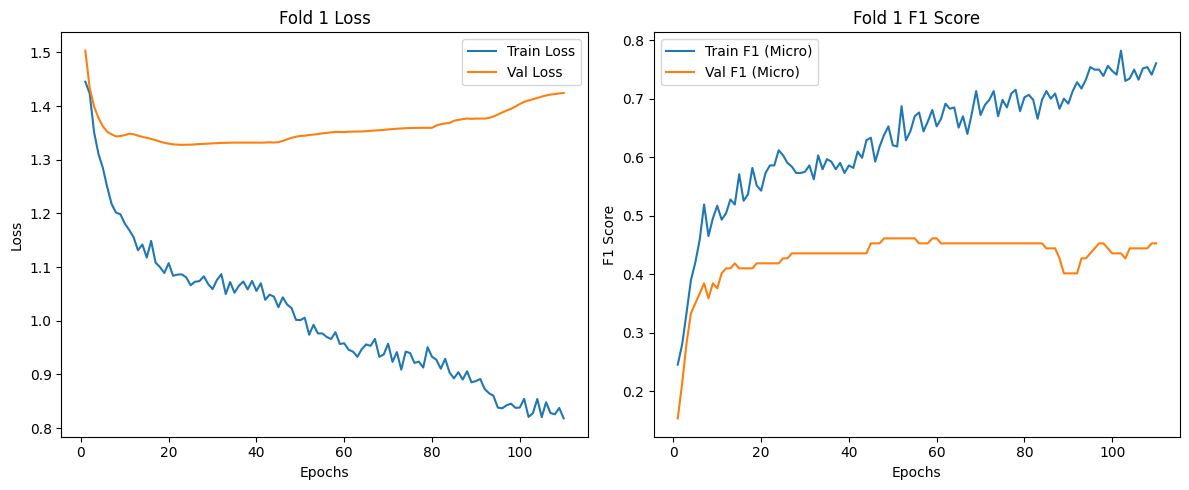

<Figure size 1000x1000 with 0 Axes>

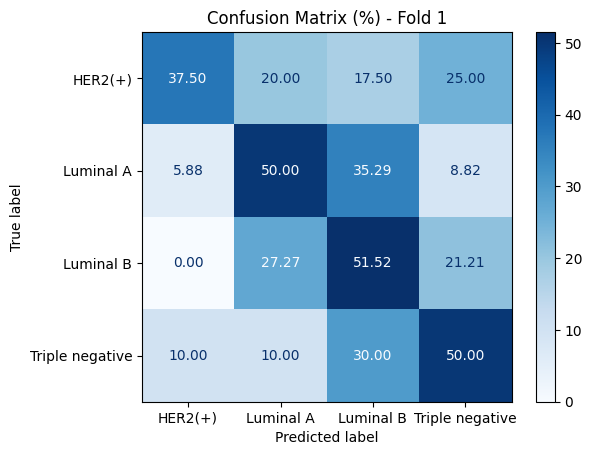

\n=== Fold 2 ===
Train Bags: 465 | Val Bags: 116
Model parameters: 30748
Epoch 5/1000: Train (Loss: 1.2802, F1: 0.4387) - Val (Loss: 1.3634, F1: 0.3448) - LR: 2.89e-03
Epoch 10/1000: Train (Loss: 1.1803, F1: 0.4989) - Val (Loss: 1.3625, F1: 0.3362) - LR: 2.56e-03
Epoch 15/1000: Train (Loss: 1.1361, F1: 0.5484) - Val (Loss: 1.3479, F1: 0.3534) - LR: 2.07e-03
Epoch 20/1000: Train (Loss: 1.0610, F1: 0.6215) - Val (Loss: 1.3477, F1: 0.3621) - LR: 1.50e-03
Epoch 25/1000: Train (Loss: 1.0491, F1: 0.5978) - Val (Loss: 1.3492, F1: 0.3621) - LR: 9.26e-04
Epoch 30/1000: Train (Loss: 1.0508, F1: 0.6301) - Val (Loss: 1.3490, F1: 0.3448) - LR: 4.39e-04
Epoch 35/1000: Train (Loss: 1.0324, F1: 0.6323) - Val (Loss: 1.3482, F1: 0.3362) - LR: 1.14e-04
Epoch 40/1000: Train (Loss: 1.0436, F1: 0.6108) - Val (Loss: 1.3481, F1: 0.3362) - LR: 3.00e-03
Epoch 45/1000: Train (Loss: 1.0120, F1: 0.6452) - Val (Loss: 1.3508, F1: 0.3621) - LR: 2.89e-03
Epoch 50/1000: Train (Loss: 0.9779, F1: 0.6667) - Val (Loss: 1.3

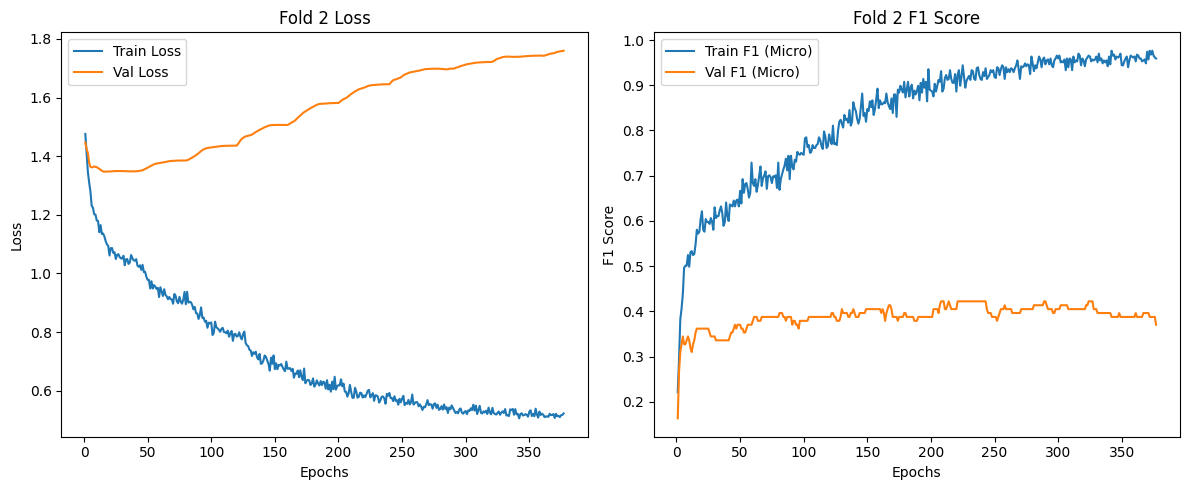

<Figure size 1000x1000 with 0 Axes>

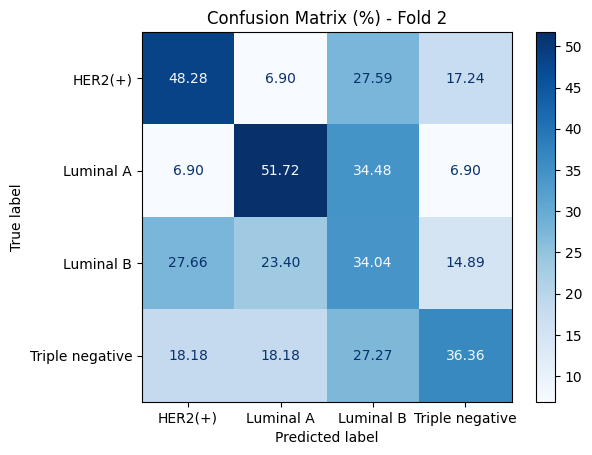

\n=== Fold 3 ===
Train Bags: 465 | Val Bags: 116
Model parameters: 30748
Epoch 5/1000: Train (Loss: 1.2968, F1: 0.3957) - Val (Loss: 1.2587, F1: 0.3793) - LR: 2.89e-03
Epoch 10/1000: Train (Loss: 1.1939, F1: 0.4925) - Val (Loss: 1.2545, F1: 0.4483) - LR: 2.56e-03
Epoch 15/1000: Train (Loss: 1.1312, F1: 0.5398) - Val (Loss: 1.2617, F1: 0.4655) - LR: 2.07e-03
Epoch 20/1000: Train (Loss: 1.0920, F1: 0.5806) - Val (Loss: 1.2580, F1: 0.4655) - LR: 1.50e-03
Epoch 25/1000: Train (Loss: 1.0710, F1: 0.6000) - Val (Loss: 1.2525, F1: 0.4569) - LR: 9.26e-04
Epoch 30/1000: Train (Loss: 1.0709, F1: 0.6301) - Val (Loss: 1.2525, F1: 0.4483) - LR: 4.39e-04
Epoch 35/1000: Train (Loss: 1.0574, F1: 0.6108) - Val (Loss: 1.2539, F1: 0.4569) - LR: 1.14e-04
Epoch 40/1000: Train (Loss: 1.0391, F1: 0.6086) - Val (Loss: 1.2540, F1: 0.4569) - LR: 3.00e-03
Epoch 45/1000: Train (Loss: 1.0219, F1: 0.6538) - Val (Loss: 1.2594, F1: 0.4483) - LR: 2.89e-03
Epoch 50/1000: Train (Loss: 1.0114, F1: 0.6602) - Val (Loss: 1.2

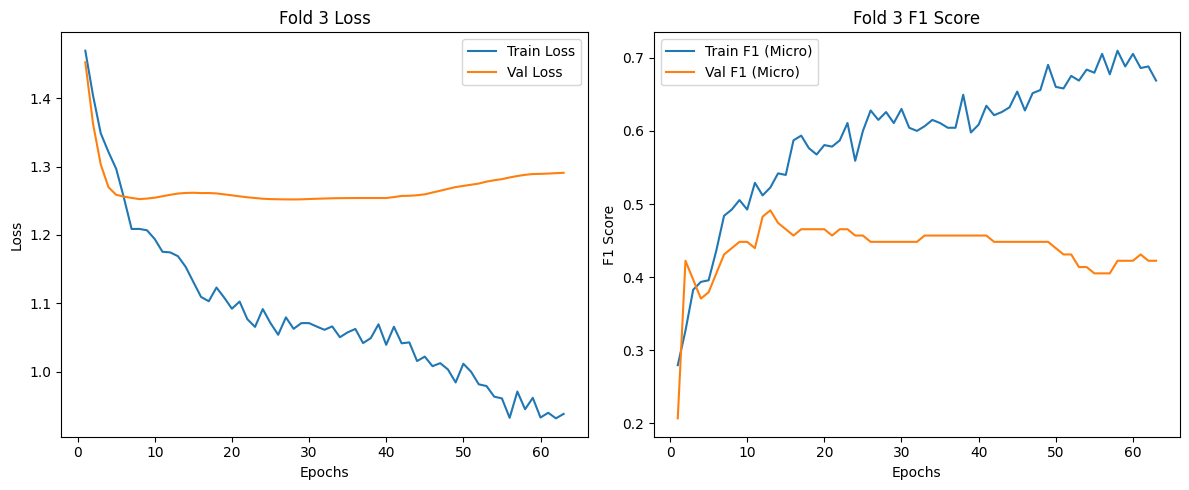

<Figure size 1000x1000 with 0 Axes>

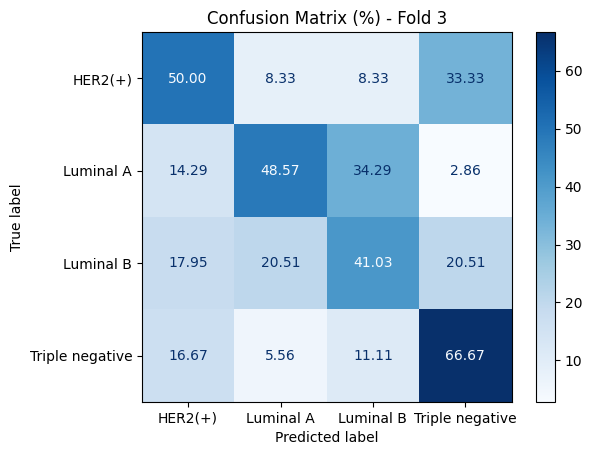

\n=== Fold 4 ===
Train Bags: 465 | Val Bags: 116
Model parameters: 30748
Epoch 5/1000: Train (Loss: 1.2969, F1: 0.4688) - Val (Loss: 1.3482, F1: 0.4224) - LR: 2.89e-03
Epoch 10/1000: Train (Loss: 1.1997, F1: 0.4946) - Val (Loss: 1.3225, F1: 0.4397) - LR: 2.56e-03
Epoch 15/1000: Train (Loss: 1.1424, F1: 0.5355) - Val (Loss: 1.3133, F1: 0.4310) - LR: 2.07e-03
Epoch 20/1000: Train (Loss: 1.1099, F1: 0.5613) - Val (Loss: 1.3157, F1: 0.4224) - LR: 1.50e-03
Epoch 25/1000: Train (Loss: 1.0747, F1: 0.6065) - Val (Loss: 1.3210, F1: 0.4224) - LR: 9.26e-04
Epoch 30/1000: Train (Loss: 1.0481, F1: 0.6043) - Val (Loss: 1.3241, F1: 0.4138) - LR: 4.39e-04
Epoch 35/1000: Train (Loss: 1.0523, F1: 0.6495) - Val (Loss: 1.3252, F1: 0.4138) - LR: 1.14e-04
Epoch 40/1000: Train (Loss: 1.0679, F1: 0.6194) - Val (Loss: 1.3252, F1: 0.4138) - LR: 3.00e-03
Epoch 45/1000: Train (Loss: 1.0314, F1: 0.6258) - Val (Loss: 1.3275, F1: 0.4138) - LR: 2.89e-03
Epoch 50/1000: Train (Loss: 0.9961, F1: 0.6731) - Val (Loss: 1.3

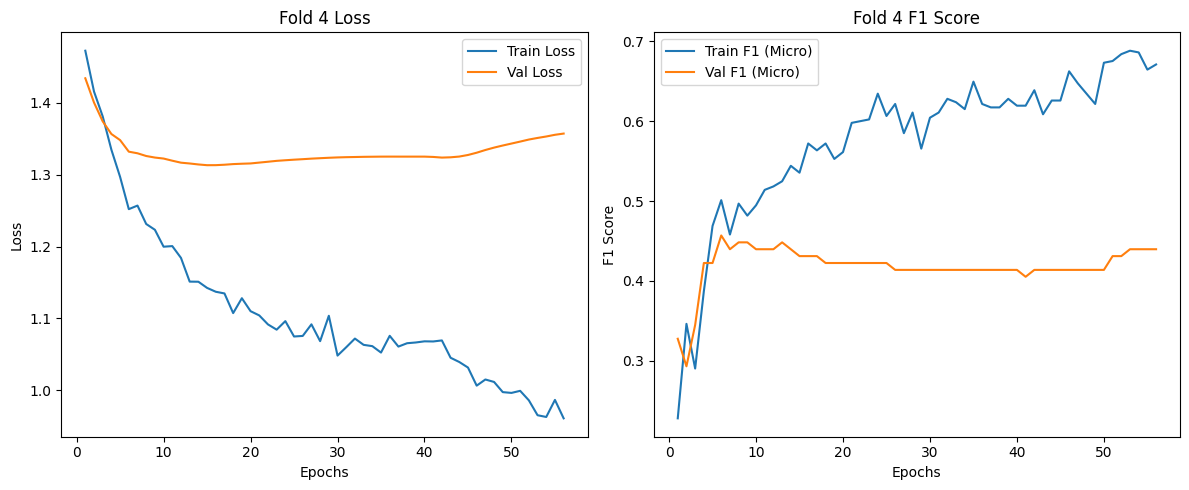

<Figure size 1000x1000 with 0 Axes>

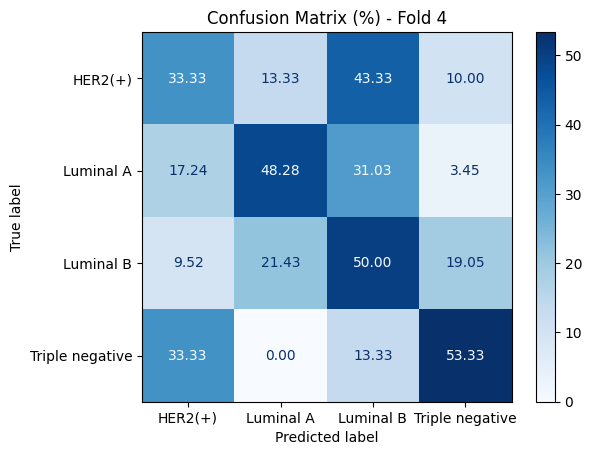

\n=== Fold 5 ===
Train Bags: 465 | Val Bags: 116
Model parameters: 30748
Epoch 5/1000: Train (Loss: 1.2613, F1: 0.4344) - Val (Loss: 1.3437, F1: 0.3707) - LR: 2.89e-03
Epoch 10/1000: Train (Loss: 1.1842, F1: 0.4946) - Val (Loss: 1.3500, F1: 0.3879) - LR: 2.56e-03
Epoch 15/1000: Train (Loss: 1.1001, F1: 0.5699) - Val (Loss: 1.3511, F1: 0.3707) - LR: 2.07e-03
Epoch 20/1000: Train (Loss: 1.0655, F1: 0.5978) - Val (Loss: 1.3573, F1: 0.3707) - LR: 1.50e-03
Epoch 25/1000: Train (Loss: 1.0604, F1: 0.5957) - Val (Loss: 1.3595, F1: 0.3793) - LR: 9.26e-04
Epoch 30/1000: Train (Loss: 1.0626, F1: 0.5914) - Val (Loss: 1.3577, F1: 0.3793) - LR: 4.39e-04
Epoch 35/1000: Train (Loss: 1.0288, F1: 0.6473) - Val (Loss: 1.3569, F1: 0.3793) - LR: 1.14e-04
Epoch 40/1000: Train (Loss: 1.0499, F1: 0.6065) - Val (Loss: 1.3569, F1: 0.3793) - LR: 3.00e-03
Epoch 45/1000: Train (Loss: 1.0153, F1: 0.6387) - Val (Loss: 1.3653, F1: 0.3879) - LR: 2.89e-03
Epoch 50/1000: Train (Loss: 0.9815, F1: 0.6753) - Val (Loss: 1.3

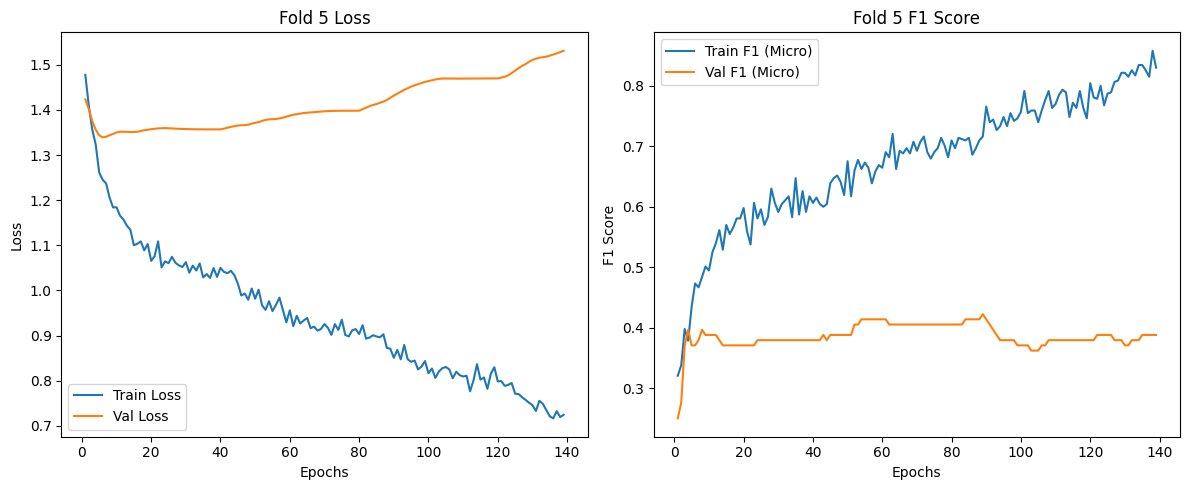

<Figure size 1000x1000 with 0 Axes>

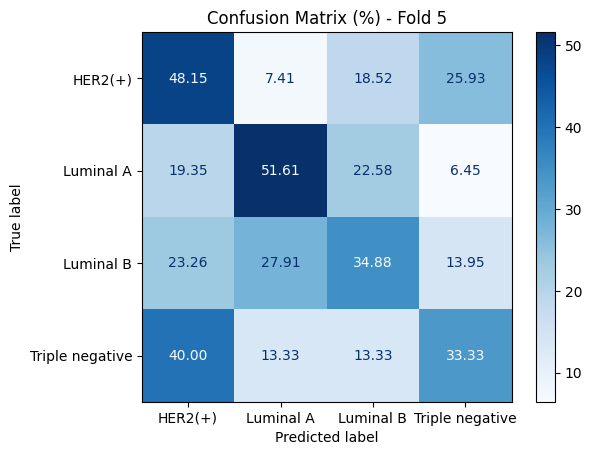

\nAverage F1 Score: 0.4509


In [35]:
# Validation loop
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_accs = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(full_train_df, full_train_df['label'], groups=full_train_df['group']), 1):
    print(f"\\n=== Fold {fold} ===")
    
    train_samples = full_train_df.iloc[train_idx]
    val_samples = full_train_df.iloc[val_idx]
        
    # # Helper to get bag name
    def get_bag_name(idx):
        if isinstance(idx, str) and 'aug' in idx:
            return idx
        else:
            return idx[:-4]

    train_bag_names = [get_bag_name(idx) for idx in train_samples['sample_index']]
    val_bag_names = [get_bag_name(idx) for idx in val_samples['sample_index']]
    
    # Check leakage - verify no original samples overlap between train and val
    train_groups = set(train_samples['group'])
    val_groups = set(val_samples['group'])
    assert len(train_groups.intersection(val_groups)) == 0, "Data Leakage Detected!"
    
    print(f"Train Bags: {len(train_bag_names)} | Val Bags: {len(val_bag_names)}")

    
    # Dataset
    train_ds = ProcessedMILDataset(
        features_path=str(FEATURES_PATH / 'features'),
        labels_path=str(FEATURES_PATH / 'labels'),
        coords_path=str(FEATURES_PATH / 'coords'),
        bag_keys=["X", "Y", "coords"],
        bag_names=train_bag_names,
        load_at_init=False
    )
    val_ds = ProcessedMILDataset(
        features_path=str(FEATURES_PATH / 'features'),
        labels_path=str(FEATURES_PATH / 'labels'),
        coords_path=str(FEATURES_PATH / 'coords'),
        bag_keys=["X", "Y", "coords"],
        bag_names=val_bag_names,
        load_at_init=False
    )
    
    torch.manual_seed(SEED + fold)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=mil_collate_fn)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate_fn)
    
    # Model
    model = MultiClassABMIL(
        in_dim=feature_extractor.feature_dim,
        att_dim=ATTENTION_DIM,
        num_classes=NUM_CLASSES,
        gated=GATED,
        dropout=DROPOUT,
    ).to(DEVICE)
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    
    # optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # AdamW + weight decay
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    #     optimizer,
    #     T_max=NUM_EPOCHS,      # number of epochs for one cosine cycle
    #     eta_min=0.0            # minimum LR
    # )
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    # criterion = FocalLoss(weight=class_weights, gamma=2.0)
    # optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # Increased weight decay
    optimizer = SOAP(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=SCHEDULER_PATIENCE, verbose=True) # Scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=40
    )
    # scheduler = None
    # Training
    best_val_acc = 0
    early_stopping = EarlyStopping(patience=PATIENCE, verbose=False, path=OUTPUT_PATH / f'model_fold_{fold}.pth')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss = 0
        train_preds = []
        train_labels = []
        
        for batch in train_loader:
            features = batch['X'].to(DEVICE)
            labels = batch['Y'].squeeze().long().to(DEVICE) 
            mask = batch['mask'].to(DEVICE) if 'mask' in batch else None 
            
            optimizer.zero_grad()
            logits = model(features, mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        train_loss = total_loss / len(train_loader)
        train_f1 = f1_score(train_labels, train_preds, average='micro')
        
        # Validation
        model.eval()
        val_loss = 0
        val_preds = []
        val_true = []
        with torch.no_grad():
            for batch in val_loader:
                features = batch['X'].to(DEVICE)
                labels = batch['Y'].squeeze().long().to(DEVICE)
                mask = batch['mask'].to(DEVICE) if 'mask' in batch else None
                
                logits = model(features, mask)
                loss = criterion(logits, labels)
                val_loss += loss.item()
                
                preds = torch.argmax(logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(val_true, val_preds, average='micro')

        # Step scheduler
        if scheduler:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

            
        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        
        # Print metrics
        if (epoch + 1) % 5 == 0: # Print every epoch for better tracking with ES
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Train (Loss: {train_loss:.4f}, F1: {train_f1:.4f}) - Val (Loss: {val_loss:.4f}, F1: {val_f1:.4f}) - LR: {current_lr:.2e}")
        
        # Early Stopping (monitor val_loss)
        early_stopping(val_f1, model)
        
        if early_stopping.early_stop:
            print("Early stopping")
            break
    
    # Load best model for fold evaluation (EarlyStopping saves best model)
    model.load_state_dict(torch.load(OUTPUT_PATH / f'model_fold_{fold}.pth'))
    
    # Let's just re-evaluate on validation set with loaded model to be sure
    model.eval()
    val_preds = []
    val_true = []
    with torch.no_grad():
         for batch in val_loader:
            features = batch['X'].to(DEVICE)
            labels = batch['Y'].squeeze().long().to(DEVICE)
            mask = batch['mask'].to(DEVICE) if 'mask' in batch else None
            logits = model(features, mask)
            preds = torch.argmax(logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())
    
    best_val_f1 = f1_score(val_true, val_preds, average='micro')
    print(f"Best Val F1 Fold {fold}: {best_val_f1:.4f}")
    fold_accs.append(best_val_f1)
    
    # Plot history
    plot_history(history, fold, OUTPUT_PATH)

    plot_confusion_matrix_percentages(val_true, val_preds, unique_labels, fold, OUTPUT_PATH)


print(f"\\nAverage F1 Score: {np.mean(fold_accs):.4f}")


In [32]:
# --- Inference ---
test_patches_df = pd.read_csv(TEST_PATCHES_CSV)

# Extract test features
print("Running feature extraction for test set...")
extract_and_save_features(
    test_patches_df,
    TEST_PATCHES_PATH,
    TEST_FEATURES_PATH,
    feature_extractor,
    label_to_idx=None, # No labels for test set,
    batch_size=1024
)

Running feature extraction for test set...


In [34]:
test_sample_indices = sorted(test_patches_df['sample_index'].unique())
test_bag_names = [f"img_{idx:04d}" for idx in test_sample_indices]

test_ds = ProcessedMILDataset(
    features_path=str(TEST_FEATURES_PATH / 'features'),
    labels_path=None, # No labels
    coords_path=str(TEST_FEATURES_PATH / 'coords'),
    bag_keys=["X", "coords"], # Only load features and coords
    bag_names=test_bag_names,
    load_at_init=False
)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate_fn)

# Ensemble predictions
avg_probs = None

for fold in range(1, N_FOLDS + 1):
    print(f"Loading model from Fold {fold}...")
    model = MultiClassABMIL(
        in_dim=feature_extractor.feature_dim,
        att_dim=ATTENTION_DIM,
        num_classes=NUM_CLASSES,
        gated=GATED,
        dropout=DROPOUT,
    ).to(DEVICE)
    # model = MaxPoolMIL(feature_extractor.feature_dim, NUM_CLASSES, DROPOUT).to(DEVICE)

    model_path = OUTPUT_PATH / f'model_fold_{fold}.pth'
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    
    fold_probs = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Inference Fold {fold}"):
            features = batch['X'].to(DEVICE)
            mask = batch['mask'].to(DEVICE) if 'mask' in batch else None
            
            logits = model(features, mask)
            probs = F.softmax(logits, dim=1)
            fold_probs.append(probs.cpu().numpy())
            
    fold_probs = np.concatenate(fold_probs, axis=0)
    
    if avg_probs is None:
        avg_probs = fold_probs
    else:
        avg_probs += fold_probs
        
avg_probs /= N_FOLDS

# Convert to labels
pred_indices = np.argmax(avg_probs, axis=1)
pred_labels = [unique_labels[idx] for idx in pred_indices]

# Create submission file
submission_df = pd.DataFrame({
    'sample_index': [f'{bag}.png' for bag in test_bag_names],
    'label': pred_labels
})

submission_path = OUTPUT_PATH / 'submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to {submission_path}")
print(submission_df.head())


Loading model from Fold 1...


Inference Fold 1: 100%|██████████| 2/2 [00:00<00:00,  8.28it/s]


Loading model from Fold 2...


Inference Fold 2: 100%|██████████| 2/2 [00:00<00:00, 17.21it/s]


Loading model from Fold 3...


...

Loading model from Fold 4...


Inference Fold 4: 100%|██████████| 2/2 [00:00<00:00, 16.55it/s]


Loading model from Fold 5...


Inference Fold 5: 100%|██████████| 2/2 [00:00<00:00, 17.21it/s]

Submission saved to /kaggle/working/submission.csv
   sample_index            label
0  img_0000.png        Luminal B
1  img_0001.png        Luminal B
2  img_0002.png  Triple negative
3  img_0003.png        Luminal B
4  img_0004.png        Luminal A
